In [1]:
from datasets import load_from_disk

dataset = load_from_disk("../data/processed/ag_news_cleaned")

print(dataset)

c:\Users\ASUS\Desktop\NLP-News-Intelligence\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 7600
    })
})


In [2]:
split_dataset = dataset["train"].train_test_split(
    test_size=0.10,
    seed=42
)

train_dataset = split_dataset["train"]
val_dataset = split_dataset["test"]
test_dataset = dataset["test"]

print("Training:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Training: 108000
Validation: 12000
Test: 7600


In [3]:
train_dataset.save_to_disk("../data/splits/train")
val_dataset.save_to_disk("../data/splits/validation")
test_dataset.save_to_disk("../data/splits/test")

print("Train, validation, and test datasets saved successfully.")

Saving the dataset (1/1 shards): 100%|██████████| 7600/7600 [00:00<00:00, 1056499.75 examples/s]

Train, validation, and test datasets saved successfully.


In [4]:
from collections import Counter
import re

In [5]:
def tokenize_text(text):
    return text.split()

In [6]:
sample = train_dataset[0]["text"]

print(sample)
print(tokenize_text(sample))

despair and anger in small russian town after siege beslan russia reuters the killing of more than children parents and teachers during the bloody end to a hour school siege left barely a family untouched in the small russian town of beslan
['despair', 'and', 'anger', 'in', 'small', 'russian', 'town', 'after', 'siege', 'beslan', 'russia', 'reuters', 'the', 'killing', 'of', 'more', 'than', 'children', 'parents', 'and', 'teachers', 'during', 'the', 'bloody', 'end', 'to', 'a', 'hour', 'school', 'siege', 'left', 'barely', 'a', 'family', 'untouched', 'in', 'the', 'small', 'russian', 'town', 'of', 'beslan']


In [7]:
counter = Counter()

for example in train_dataset:
    counter.update(tokenize_text(example["text"]))

print("Unique words:", len(counter))
print("Most common words:")
print(counter.most_common(20))

Unique words: 59529
Most common words:
[('the', 185045), ('to', 108663), ('a', 102307), ('of', 88873), ('in', 86764), ('and', 62712), ('s', 56138), ('on', 51856), ('for', 45544), ('that', 25371), ('with', 24126), ('as', 22827), ('at', 22575), ('its', 19843), ('is', 19838), ('new', 19271), ('by', 18874), ('it', 18532), ('said', 18231), ('has', 17116)]


In [8]:
MAX_VOCAB_SIZE = 20000

most_common_words = counter.most_common(MAX_VOCAB_SIZE - 2)

print("Vocabulary words:", len(most_common_words))

Vocabulary words: 19998


In [9]:
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"

vocab = {
    PAD_TOKEN: 0,
    UNK_TOKEN: 1
}

for index, (word, count) in enumerate(most_common_words, start=2):
    vocab[word] = index

print("Vocabulary size:", len(vocab))

print("\nSample vocabulary:")
for word, index in list(vocab.items())[:20]:
    print(word, "->", index)

Vocabulary size: 20000

Sample vocabulary:
<pad> -> 0
<unk> -> 1
the -> 2
to -> 3
a -> 4
of -> 5
in -> 6
and -> 7
s -> 8
on -> 9
for -> 10
that -> 11
with -> 12
as -> 13
at -> 14
its -> 15
is -> 16
new -> 17
by -> 18
it -> 19


In [10]:
def text_to_sequence(text, vocab):
    tokens = tokenize_text(text)

    sequence = [
        vocab.get(token, vocab[UNK_TOKEN])
        for token in tokens
    ]

    return sequence

In [11]:
sample_text = train_dataset[0]["text"]

sequence = text_to_sequence(sample_text, vocab)

print("Original text:")
print(sample_text)

print("\nToken IDs:")
print(sequence)

print("\nNumber of tokens:", len(sequence))

Original text:
despair and anger in small russian town after siege beslan russia reuters the killing of more than children parents and teachers during the bloody end to a hour school siege left barely a family untouched in the small russian town of beslan

Token IDs:
[13162, 7, 3924, 6, 592, 339, 952, 28, 2689, 2947, 319, 23, 2, 457, 5, 44, 61, 859, 2977, 7, 6564, 226, 2, 3393, 134, 3, 4, 1735, 482, 2689, 270, 3441, 4, 821, 13163, 6, 2, 592, 339, 952, 5, 2947]

Number of tokens: 42


In [12]:
unknown_count = sequence.count(vocab[UNK_TOKEN])

print("Unknown tokens:", unknown_count)

Unknown tokens: 0


In [13]:
MAX_LENGTH = 100
PAD_INDEX = vocab[PAD_TOKEN]


def pad_sequence(sequence, max_length=MAX_LENGTH):
    if len(sequence) < max_length:
        sequence = sequence + [PAD_INDEX] * (max_length - len(sequence))
    else:
        sequence = sequence[:max_length]

    return sequence

In [14]:
padded_sequence = pad_sequence(sequence)

print("Original length:", len(sequence))
print("Padded length:", len(padded_sequence))
print("Padded sequence:")
print(padded_sequence)

Original length: 42
Padded length: 100
Padded sequence:
[13162, 7, 3924, 6, 592, 339, 952, 28, 2689, 2947, 319, 23, 2, 457, 5, 44, 61, 859, 2977, 7, 6564, 226, 2, 3393, 134, 3, 4, 1735, 482, 2689, 270, 3441, 4, 821, 13163, 6, 2, 592, 339, 952, 5, 2947, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [15]:
long_text = train_dataset[100]["text"]

long_sequence = text_to_sequence(long_text, vocab)
long_padded = pad_sequence(long_sequence)

print("Original token length:", len(long_sequence))
print("Final sequence length:", len(long_padded))

Original token length: 61
Final sequence length: 100


In [16]:
import torch
from torch.utils.data import Dataset


class NewsDataset(Dataset):

    def __init__(self, dataset, vocab, max_length=100):
        self.dataset = dataset
        self.vocab = vocab
        self.max_length = max_length

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):

        text = self.dataset[index]["text"]
        label = self.dataset[index]["label"]

        # Convert text to token IDs
        sequence = text_to_sequence(text, self.vocab)

        # Pad sequence
        sequence = pad_sequence(sequence, self.max_length)

        # Convert to PyTorch tensors
        sequence = torch.tensor(sequence, dtype=torch.long)
        label = torch.tensor(label, dtype=torch.long)

        return sequence, label

In [17]:
train_torch_dataset = NewsDataset(
    train_dataset,
    vocab,
    MAX_LENGTH
)

val_torch_dataset = NewsDataset(
    val_dataset,
    vocab,
    MAX_LENGTH
)

test_torch_dataset = NewsDataset(
    test_dataset,
    vocab,
    MAX_LENGTH
)

print("Training samples:", len(train_torch_dataset))
print("Validation samples:", len(val_torch_dataset))
print("Test samples:", len(test_torch_dataset))

Training samples: 108000
Validation samples: 12000
Test samples: 7600


In [18]:
sample_sequence, sample_label = train_torch_dataset[0]

print("Sequence shape:", sample_sequence.shape)
print("Label:", sample_label)
print("First 20 token IDs:", sample_sequence[:20])

Sequence shape: torch.Size([100])
Label: tensor(0)
First 20 token IDs: tensor([13162,     7,  3924,     6,   592,   339,   952,    28,  2689,  2947,
          319,    23,     2,   457,     5,    44,    61,   859,  2977,     7])


In [19]:
from torch.utils.data import DataLoader

BATCH_SIZE = 64

train_loader = DataLoader(
    train_torch_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_torch_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_torch_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 1688
Validation batches: 188
Test batches: 119


In [20]:
batch_sequences, batch_labels = next(iter(train_loader))

print("Batch sequences shape:", batch_sequences.shape)
print("Batch labels shape:", batch_labels.shape)

print("First sequence:")
print(batch_sequences[0])

print("First label:")
print(batch_labels[0])

Batch sequences shape: torch.Size([64, 100])
Batch labels shape: torch.Size([64])
First sequence:
tensor([ 1060, 16609,  2458,   600,   336,   236, 12434,  1060,    21,    81,
            2,   927,     5,   141,  2842,   566,     1,     7,  1060,     1,
          117, 11850,    16,     2,    39,    49,     3,   238,    11,    19,
           16,    45,    57,     2,   289,    70,   396,  2979,     2,  2876,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0])
First label:
tensor(1)


In [21]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.pytorch.model import NewsClassifier

In [22]:
model = NewsClassifier(
    vocab_size=len(vocab),
    embedding_dim=128,
    hidden_dim=128,
    num_classes=4,
    dropout=0.3
)

print(model)

NewsClassifier(
  (embedding): Embedding(20000, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True, bidirectional=True)
  (attention): Linear(in_features=256, out_features=1, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=4, bias=True)
)


In [23]:
batch_sequences, batch_labels = next(iter(train_loader))

outputs = model(batch_sequences)

print("Input shape:", batch_sequences.shape)
print("Output shape:", outputs.shape)
print("Outputs:")
print(outputs)

Input shape: torch.Size([64, 100])
Output shape: torch.Size([64, 4])
Outputs:
tensor([[ 0.0507, -0.0337,  0.0036, -0.0850],
        [ 0.0468, -0.0248, -0.0026, -0.1105],
        [ 0.0045, -0.0112, -0.0147, -0.1218],
        [ 0.0184, -0.0474, -0.0155, -0.0729],
        [ 0.0311, -0.0616, -0.0451, -0.0925],
        [ 0.0426, -0.0484, -0.0241, -0.0852],
        [ 0.0490, -0.0032, -0.0355, -0.1051],
        [ 0.0208, -0.0531, -0.0506, -0.1028],
        [ 0.0216, -0.0315, -0.0187, -0.0681],
        [ 0.0298, -0.0424, -0.0322, -0.0522],
        [ 0.0264, -0.0329, -0.0310, -0.1030],
        [ 0.0214, -0.0262, -0.0158, -0.0901],
        [ 0.0120, -0.0398, -0.0385, -0.0988],
        [ 0.0351, -0.0129, -0.0067, -0.0891],
        [ 0.0286, -0.0278, -0.0397, -0.0924],
        [ 0.0650, -0.0136, -0.0597, -0.1087],
        [ 0.0659, -0.0453, -0.0387, -0.0597],
        [ 0.0339, -0.0376, -0.0384, -0.0813],
        [ 0.0415, -0.0472,  0.0068, -0.0899],
        [ 0.0452, -0.0253, -0.0235, -0.1214],
  

In [24]:
import torch
import torch.nn as nn

# Use GPU if available, otherwise CPU
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cpu


In [25]:
model = model.to(device)

print("Model moved to:", device)

Model moved to: cpu


In [26]:
criterion = nn.CrossEntropyLoss()

print("Loss function:", criterion)

Loss function: CrossEntropyLoss()


In [27]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Optimizer:", optimizer)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [28]:
print("Device:", device)
print("Number of classes:", 4)
print("Vocabulary size:", len(vocab))
print("Learning rate:", 0.001)

Device: cpu
Number of classes: 4
Vocabulary size: 20000
Learning rate: 0.001


In [29]:
def train_one_epoch(model, data_loader, criterion, optimizer, device):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for sequences, labels in data_loader:

        # Move data to CPU/GPU
        sequences = sequences.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(sequences)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update model weights
        optimizer.step()

        # Track loss
        total_loss += loss.item()

        # Calculate predictions
        predictions = torch.argmax(outputs, dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    average_loss = total_loss / len(data_loader)
    accuracy = correct / total

    return average_loss, accuracy

In [30]:
train_loss, train_accuracy = train_one_epoch(
    model,
    train_loader,
    criterion,
    optimizer,
    device
)

print("Training Loss:", train_loss)
print("Training Accuracy:", train_accuracy)

Training Loss: 0.462816822271953
Training Accuracy: 0.8309537037037037


In [31]:
def evaluate_model(model, data_loader, criterion, device):

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for sequences, labels in data_loader:

            sequences = sequences.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(sequences)

            # Calculate loss
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            # Predictions
            predictions = torch.argmax(outputs, dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    average_loss = total_loss / len(data_loader)
    accuracy = correct / total

    return average_loss, accuracy

In [32]:
val_loss, val_accuracy = evaluate_model(
    model,
    val_loader,
    criterion,
    device
)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

Validation Loss: 0.31130511868507305
Validation Accuracy: 0.8945833333333333


In [33]:
from pathlib import Path

model_dir = Path("../models/pytorch")
model_dir.mkdir(parents=True, exist_ok=True)

best_model_path = model_dir / "best_news_classifier.pt"

print("Model will be saved to:")
print(best_model_path)

Model will be saved to:
..\models\pytorch\best_news_classifier.pt


In [34]:
NUM_EPOCHS = 5

best_val_accuracy = 0.0

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

for epoch in range(NUM_EPOCHS):

    print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")

    # Training
    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    # Validation
    val_loss, val_accuracy = evaluate_model(
        model,
        val_loader,
        criterion,
        device
    )

    # Save history
    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_accuracy:.4f}")
    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {val_accuracy:.4f}")

    # Save the best model
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            model.state_dict(),
            best_model_path
        )

        print("✓ Best model saved!")


Epoch 1/5
Train Loss: 0.2528
Train Accuracy: 0.9155
Validation Loss: 0.2689
Validation Accuracy: 0.9080
✓ Best model saved!

Epoch 2/5
Train Loss: 0.1935
Train Accuracy: 0.9352
Validation Loss: 0.2550
Validation Accuracy: 0.9143
✓ Best model saved!

Epoch 3/5
Train Loss: 0.1539
Train Accuracy: 0.9481
Validation Loss: 0.2695
Validation Accuracy: 0.9131

Epoch 4/5
Train Loss: 0.1163
Train Accuracy: 0.9611
Validation Loss: 0.2975
Validation Accuracy: 0.9123

Epoch 5/5
Train Loss: 0.0887
Train Accuracy: 0.9698
Validation Loss: 0.3128
Validation Accuracy: 0.9113


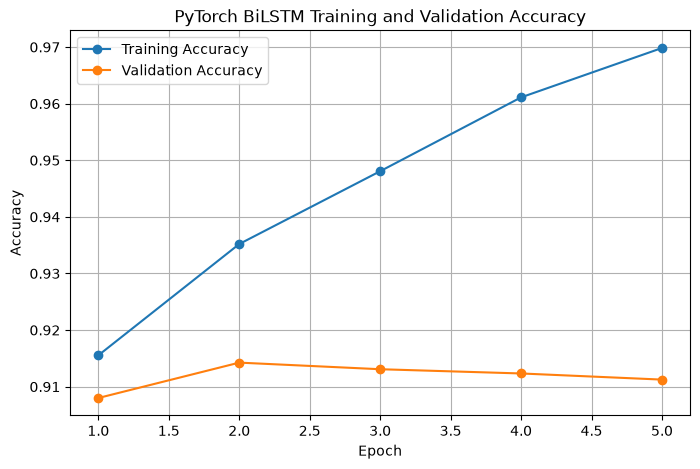

In [35]:
import matplotlib.pyplot as plt

epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("PyTorch BiLSTM Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

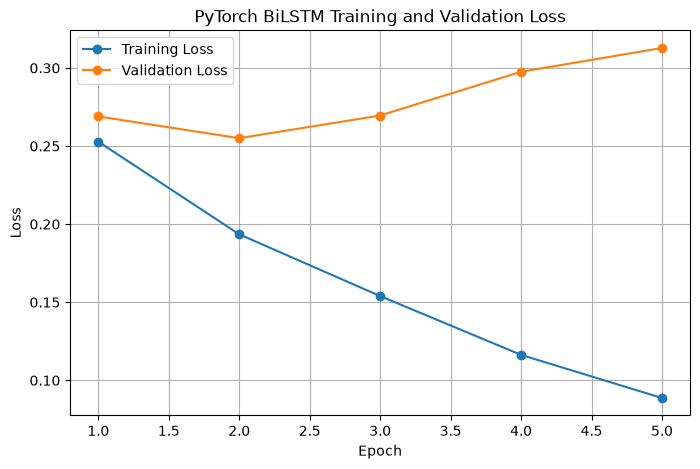

In [36]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("PyTorch BiLSTM Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [37]:
# Load the best model saved during training

best_model = NewsClassifier(
    vocab_size=len(vocab),
    embedding_dim=128,
    hidden_dim=128,
    num_classes=4,
    dropout=0.3
)

best_model.load_state_dict(
    torch.load(
        best_model_path,
        map_location=device
    )
)

best_model = best_model.to(device)

print("Best model loaded successfully.")

Best model loaded successfully.


In [38]:
test_loss, test_accuracy = evaluate_model(
    best_model,
    test_loader,
    criterion,
    device
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.26673694624870764
Test Accuracy: 0.9118421052631579


In [39]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [40]:
all_predictions = []
all_labels = []

best_model.eval()

with torch.no_grad():

    for sequences, labels in test_loader:

        sequences = sequences.to(device)
        labels = labels.to(device)

        outputs = best_model(sequences)

        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

print("Predictions collected:", len(all_predictions))
print("True labels collected:", len(all_labels))

Predictions collected: 7600
True labels collected: 7600


In [41]:
class_names = [
    "World",
    "Sports",
    "Business",
    "Sci/Tech"
]

report = classification_report(
    all_labels,
    all_predictions,
    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

       World       0.93      0.90      0.92      1900
      Sports       0.95      0.98      0.96      1900
    Business       0.89      0.86      0.88      1900
    Sci/Tech       0.88      0.91      0.89      1900

    accuracy                           0.91      7600
   macro avg       0.91      0.91      0.91      7600
weighted avg       0.91      0.91      0.91      7600



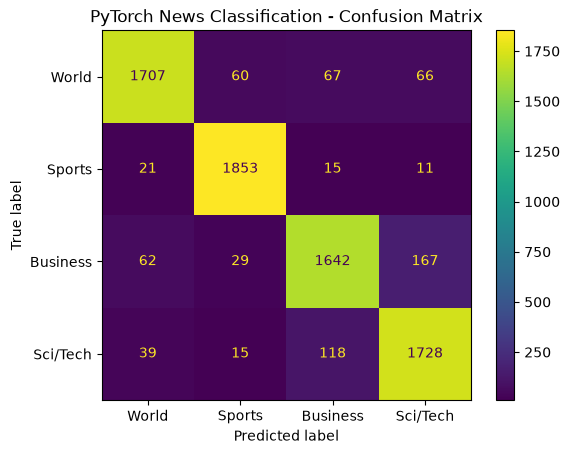

In [42]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot()

plt.title("PyTorch News Classification - Confusion Matrix")
plt.show()

In [43]:
from pathlib import Path

results_dir = Path("../results/metrics")
results_dir.mkdir(parents=True, exist_ok=True)

plots_dir = Path("../results/plots")
plots_dir.mkdir(parents=True, exist_ok=True)

predictions_dir = Path("../results/predictions")
predictions_dir.mkdir(parents=True, exist_ok=True)

print("Result folders ready.")

Result folders ready.


In [44]:
import pandas as pd

report_dict = classification_report(
    all_labels,
    all_predictions,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()

report_df.to_csv(
    results_dir / "pytorch_classification_report.csv"
)

print("Classification report saved.")

Classification report saved.


In [45]:
import numpy as np

cm = confusion_matrix(
    all_labels,
    all_predictions
)

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

cm_df.to_csv(
    results_dir / "pytorch_confusion_matrix.csv"
)

print("Confusion matrix saved.")

Confusion matrix saved.


In [46]:
prediction_df = pd.DataFrame({
    "true_label": [
        class_names[label]
        for label in all_labels
    ],
    "predicted_label": [
        class_names[prediction]
        for prediction in all_predictions
    ]
})

prediction_df.to_csv(
    predictions_dir / "pytorch_test_predictions.csv",
    index=False
)

print("Test predictions saved.")

Test predictions saved.


In [47]:
history_df = pd.DataFrame(history)

history_df.insert(
    0,
    "epoch",
    range(1, len(history_df) + 1)
)

history_df.to_csv(
    results_dir / "pytorch_training_history.csv",
    index=False
)

print("Training history saved.")

Training history saved.


<Figure size 800x600 with 0 Axes>

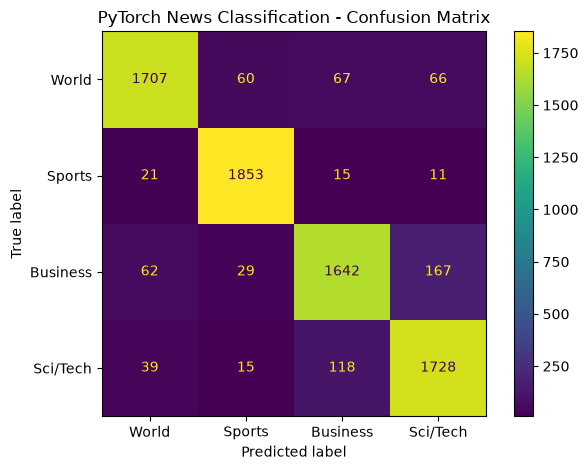

In [48]:
plt.figure(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot()

plt.title("PyTorch News Classification - Confusion Matrix")
plt.tight_layout()

plt.savefig(
    plots_dir / "pytorch_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

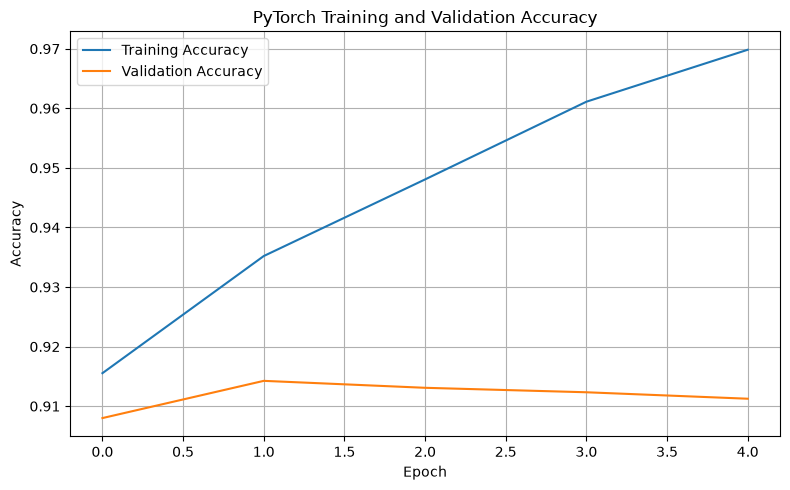

In [49]:
plt.figure(figsize=(8, 5))

plt.plot(
    history["train_accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("PyTorch Training and Validation Accuracy")
plt.legend()
plt.grid()

plt.tight_layout()

plt.savefig(
    plots_dir / "pytorch_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

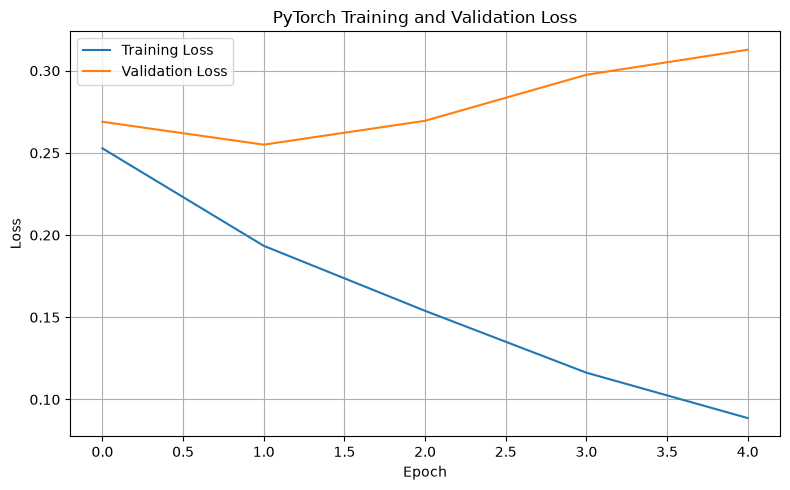

In [50]:
plt.figure(figsize=(8, 5))

plt.plot(
    history["train_loss"],
    label="Training Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("PyTorch Training and Validation Loss")
plt.legend()
plt.grid()

plt.tight_layout()

plt.savefig(
    plots_dir / "pytorch_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [51]:
import json
from pathlib import Path

vocab_path = Path("../data/processed/vocab.json")

with open(vocab_path, "w", encoding="utf-8") as file:
    json.dump(vocab, file)

print("Vocabulary saved.")
print("Vocabulary size:", len(vocab))

Vocabulary saved.
Vocabulary size: 20000
